# Q-Learning ile FrozenLake Ortamını Çözmek

**İş Problemi:** Bir ajanın, buzlu bir gölün üzerinde (4x4'lük ızgara) başlangıç noktasından hedefe,
buz deliklerine düşmeden ulaşmasını sağlayacak bir strateji (politika) öğrenmesi.

Bu notebook, [21.2.1-Q_Learning_Nedir.pdf](21.2.1-Q_Learning_Nedir.pdf) dosyasında anlatılan Bellman
güncelleme kuralının uçtan uca, çalışan bir Python uygulamasıdır. Teorik arka plan için önce o dosyayı
okumanızı öneririz.

Gerekli kütüphaneyi kurmak için: `pip install gymnasium`

## 1. Ortamın Kurulumu

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action="ignore")

In [2]:
# is_slippery=True -> buz kaygandır, seçilen eylem %33 ihtimalle yan yönlere kayabilir (stokastik ortam).
# Bu, gerçek dünyadaki belirsizliği simüle eder ve öğrenmeyi zorlaştırır.
env = gym.make("FrozenLake-v1", is_slippery=True)

n_states = env.observation_space.n   # 16 durum (4x4 ızgara)
n_actions = env.action_space.n       # 4 eylem (0: Sol, 1: Aşağı, 2: Sağ, 3: Yukarı)

print(f"Durum sayısı: {n_states}, Eylem sayısı: {n_actions}")

Durum sayısı: 16, Eylem sayısı: 4


## 2. Q-Tablosunun ve Hiperparametrelerin Tanımlanması

Q-tablosu, her (durum, eylem) çifti için öğrenilen "kalite" değerini tutar. Başlangıçta ajan hiçbir şey
bilmediği için tüm değerler sıfırdır.

In [3]:
q_table = np.zeros((n_states, n_actions))

alpha = 0.1          # Öğrenme oranı (düşük tutulur: kaygan/stokastik ortamda büyük alpha kararsızlığa yol açar)
gamma = 0.99         # İndirim faktörü (ajan ne kadar "sabırlı")
epsilon = 1.0        # Başlangıç keşif oranı (tamamen rastgele başla)
epsilon_min = 0.01
epsilon_decay = 0.9997

n_episodes = 25000
max_steps_per_episode = 100

## 3. Eğitim Döngüsü (Q-Learning)

Her adımda ε-greedy stratejisiyle bir eylem seçilir, Bellman güncelleme kuralı uygulanır:

`Q(s,a) <- Q(s,a) + alpha * [ r + gamma * max_a' Q(s',a') - Q(s,a) ]`

In [4]:
rewards_per_episode = []

for episode in range(n_episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps_per_episode):
        # Epsilon-Greedy eylem seçimi: ya keşfet (rastgele) ya da sömür (en iyi bilineni seç).
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state, :])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        best_next_q = np.max(q_table[next_state, :])
        td_target = reward + gamma * best_next_q
        td_error = td_target - q_table[state, action]
        q_table[state, action] += alpha * td_error

        state = next_state
        total_reward += reward

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

print("Eğitim tamamlandı.")

Eğitim tamamlandı.


## 4. Öğrenme Performansının Görselleştirilmesi

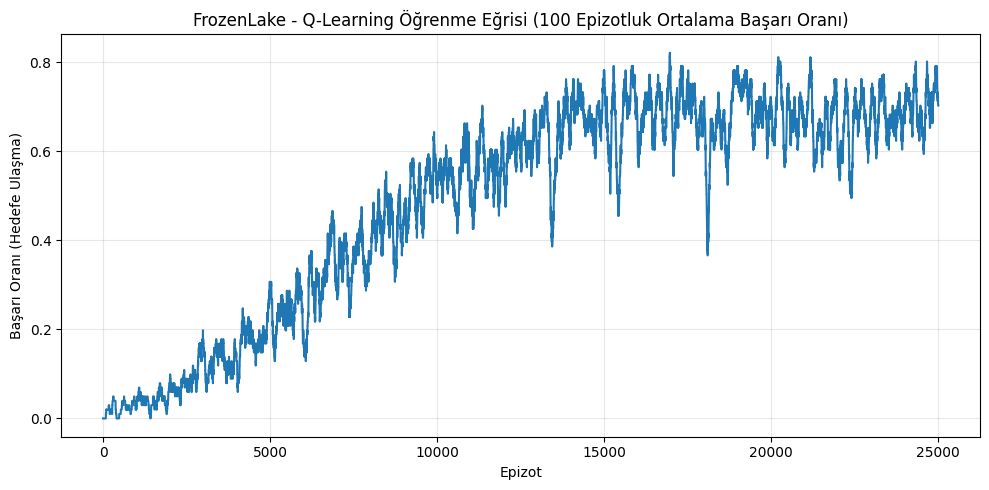

Son 1000 epizotun ortalama başarı oranı: 70.80%


In [5]:
window = 100
success_rate = [
    np.mean(rewards_per_episode[max(0, i - window):i + 1])
    for i in range(len(rewards_per_episode))
]

plt.figure(figsize=(10, 5))
plt.plot(success_rate)
plt.title("FrozenLake - Q-Learning Öğrenme Eğrisi (100 Epizotluk Ortalama Başarı Oranı)")
plt.xlabel("Epizot")
plt.ylabel("Başarı Oranı (Hedefe Ulaşma)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Son 1000 epizotun ortalama başarı oranı: {np.mean(rewards_per_episode[-1000:]):.2%}")

## 5. Öğrenilen Q-Tablosunu İnceleme

In [6]:
print("Öğrenilen Q-Tablosu (satırlar: durum 0-15, sütunlar: Sol, Aşağı, Sağ, Yukarı):")
print(np.round(q_table, 3))

Öğrenilen Q-Tablosu (satırlar: durum 0-15, sütunlar: Sol, Aşağı, Sağ, Yukarı):
[[0.546 0.524 0.534 0.54 ]
 [0.316 0.401 0.337 0.531]
 [0.411 0.418 0.416 0.507]
 [0.267 0.319 0.251 0.479]
 [0.569 0.34  0.381 0.3  ]
 [0.    0.    0.    0.   ]
 [0.233 0.136 0.524 0.135]
 [0.    0.    0.    0.   ]
 [0.437 0.536 0.378 0.607]
 [0.465 0.649 0.372 0.42 ]
 [0.694 0.433 0.343 0.245]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.565 0.572 0.76  0.54 ]
 [0.748 0.871 0.811 0.715]
 [0.    0.    0.    0.   ]]


In [7]:
# Her durum için ajanın öğrendiği en iyi eylemi okunabilir bir haritaya dönüştürelim.
# NOT: Ok karakterleri yerine ASCII sembolleri kullanılıyor; bazı Windows konsollarının
# varsayılan kod sayfası (cp1254 vb.) Unicode ok karakterlerini yazdıramayıp hataya düşebiliyor.
action_symbols = {0: "<", 1: "v", 2: ">", 3: "^"}
learned_policy = np.array([action_symbols[np.argmax(q_table[s, :])] for s in range(n_states)])
print("Öğrenilen Politika (4x4 ızgara):")
print(learned_policy.reshape(4, 4))

Öğrenilen Politika (4x4 ızgara):
[['<' '^' '^' '^']
 ['<' '<' '>' '<']
 ['^' 'v' '<' '<']
 ['<' '>' 'v' '<']]


## 6. Öğrenilmiş Politikayla Test Etme

Artık eğitim bitti; epsilon=0 kabul edip (tamamen sömürü) ajanın gerçekten hedefe ulaşıp ulaşamadığını
birkaç epizotluk bir testle doğrulayalım.

In [8]:
test_episodes = 100
test_successes = 0

for _ in range(test_episodes):
    state, _ = env.reset()
    for _ in range(max_steps_per_episode):
        action = np.argmax(q_table[state, :])
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            test_successes += reward
            break

print(f"Test sonucu ({test_episodes} epizot, tamamen öğrenilen politika ile): "
      f"{test_successes:.0f}/{test_episodes} başarı ({test_successes / test_episodes:.2%})")

env.close()

Test sonucu (100 epizot, tamamen öğrenilen politika ile): 72/100 başarı (72.00%)


## Sonuç

Ajan, hiçbir açık kural verilmeden, sadece deneme-yanılma ve Bellman güncelleme kuralı ile FrozenLake'in
kaygan/stokastik ortamında hedefe ulaşmayı öğrendi. Öğrenilen politikanın test başarı oranı, rastgele
davranan bir ajanın başarı oranından (ortalama ~%1-2) çok daha yüksektir — bu da Q-Learning'in gerçekten
çalıştığının somut kanıtıdır.

Sıradaki dosya: [21.3.1-Policy_Gradient_ve_DQN.pdf](../21.3-Policy_Gradient_ve_Deep_RL/21.3.1-Policy_Gradient_ve_DQN.pdf)
ve [21.3.2_dqn_cartpole.ipynb](../21.3-Policy_Gradient_ve_Deep_RL/21.3.2_dqn_cartpole.ipynb) — durum uzayı
sürekli olduğunda (Q-tablosu artık mümkün olmadığında) kullanılan politika gradyanı yaklaşımı.